In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving subject_info.csv to subject_info.csv


In [ ]:
df = pd.read_csv("subject_info.csv")

In [ ]:
print(df.shape)

print(df.head())

print(df['label'].value_counts())

(4194, 97)
   EEG Fp1_delta  EEG Fp1_theta  EEG Fp1_alpha  EEG Fp1_beta  EEG Fp1_gamma  \
0   6.436305e-12   1.182454e-11   3.042999e-12  1.889170e-11   2.879951e-12   
1   1.340622e-11   1.236175e-11   5.700938e-12  2.705645e-11   4.293888e-12   
2   1.845366e-11   1.073781e-11   5.406237e-12  4.848722e-11   7.746098e-12   
3   2.176090e-11   9.066191e-12   7.970467e-12  5.813862e-11   5.656470e-12   
4   1.996831e-11   5.768941e-12   4.627795e-12  4.188337e-11   6.251035e-12   

   EEG Fp2_delta  EEG Fp2_theta  EEG Fp2_alpha  EEG Fp2_beta  EEG Fp2_gamma  \
0   1.457261e-11   1.435582e-11   3.090983e-12  2.352432e-11   3.933917e-12   
1   3.176397e-11   1.948057e-11   8.761605e-12  3.809809e-11   5.474318e-12   
2   4.198800e-11   1.677002e-11   9.345011e-12  7.273812e-11   1.093414e-11   
3   4.197619e-11   9.640280e-12   1.211551e-11  8.147810e-11   8.730566e-12   
4   3.131715e-11   8.198447e-12   7.217713e-12  5.041154e-11   8.320758e-12   

   ...  EEG Cz_alpha   EEG Cz_beta  EEG

In [ ]:
channels = [
    'Fp1','Fp2','F3','F4','F7','F8',
    'T3','T4','C3','C4',
    'T5','T6','P3','P4',
    'O1','O2','Fz','Cz','Pz'
]

bands = ['delta','theta','alpha','beta','gamma']

In [ ]:
feature_dict = {}

for ch in channels:

    # -----------------------------
    # Extract band powers
    # -----------------------------
    delta = df[f'EEG {ch}_delta']
    theta = df[f'EEG {ch}_theta']
    alpha = df[f'EEG {ch}_alpha']
    beta  = df[f'EEG {ch}_beta']
    gamma = df[f'EEG {ch}_gamma']

    total = delta + theta + alpha + beta + gamma + 1e-6

    # =============================
    # BASE FEATURES
    # =============================

    feature_dict[f'{ch}_delta'] = delta
    feature_dict[f'{ch}_theta'] = theta
    feature_dict[f'{ch}_alpha'] = alpha
    feature_dict[f'{ch}_beta']  = beta
    feature_dict[f'{ch}_gamma'] = gamma

    # =============================
    # RELATIVE POWERS
    # =============================

    feature_dict[f'{ch}_delta_rel'] = delta / total
    feature_dict[f'{ch}_theta_rel'] = theta / total
    feature_dict[f'{ch}_alpha_rel'] = alpha / total
    feature_dict[f'{ch}_beta_rel']  = beta / total
    feature_dict[f'{ch}_gamma_rel'] = gamma / total

    # =============================
    # RATIOS
    # =============================

    feature_dict[f'{ch}_theta_alpha'] = theta / (alpha + 1e-6)

    feature_dict[f'{ch}_beta_alpha'] = beta / (alpha + 1e-6)

    feature_dict[f'{ch}_theta_beta_alpha'] = (
        theta + beta
    ) / (alpha + 1e-6)

    feature_dict[f'{ch}_gamma_beta'] = gamma / (beta + 1e-6)

    feature_dict[f'{ch}_alpha_delta'] = alpha / (delta + 1e-6)

    feature_dict[f'{ch}_beta_ratio'] = (
        beta / (alpha + theta + 1e-6)
    )

    # =============================
    # DIFFERENCES
    # =============================

    feature_dict[f'{ch}_beta_minus_alpha'] = beta - alpha

    feature_dict[f'{ch}_theta_minus_beta'] = theta - beta



In [ ]:
X_final = pd.DataFrame(feature_dict)

X_final['label'] = df['label']

In [ ]:
print(X_final.shape)

print(X_final.head())

(4194, 343)
      Fp1_delta     Fp1_theta     Fp1_alpha      Fp1_beta     Fp1_gamma  \
0  6.436305e-12  1.182454e-11  3.042999e-12  1.889170e-11  2.879951e-12   
1  1.340622e-11  1.236175e-11  5.700938e-12  2.705645e-11  4.293888e-12   
2  1.845366e-11  1.073781e-11  5.406237e-12  4.848722e-11  7.746098e-12   
3  2.176090e-11  9.066191e-12  7.970467e-12  5.813862e-11  5.656470e-12   
4  1.996831e-11  5.768941e-12  4.627795e-12  4.188337e-11  6.251035e-12   

   Fp1_delta_rel  Fp1_theta_rel  Fp1_alpha_rel  Fp1_beta_rel  Fp1_gamma_rel  \
0       0.000006       0.000012       0.000003      0.000019       0.000003   
1       0.000013       0.000012       0.000006      0.000027       0.000004   
2       0.000018       0.000011       0.000005      0.000048       0.000008   
3       0.000022       0.000009       0.000008      0.000058       0.000006   
4       0.000020       0.000006       0.000005      0.000042       0.000006   

   ...  Pz_gamma_rel  Pz_theta_alpha  Pz_beta_alpha  Pz_theta_

In [ ]:
# ============================================
# PRINT ALL GENERATED FEATURES CHANNEL-WISE
# ============================================

all_features = list(feature_dict.keys())

# ============================================
# GROUP FEATURES BY CHANNEL
# ============================================

channel_feature_dict = {}

for feature in all_features:

    # Example:
    # C4_beta_rel

    channel = feature.split("_")[0]

    if channel not in channel_feature_dict:
        channel_feature_dict[channel] = []

    channel_feature_dict[channel].append(feature)

# ============================================
# PRINT FEATURES
# ============================================

for channel, features in channel_feature_dict.items():

    print("\n===================================")
    print(f"CHANNEL : {channel}")
    print("===================================")

    for f in features:
        print(f)


CHANNEL : Fp1
Fp1_delta
Fp1_theta
Fp1_alpha
Fp1_beta
Fp1_gamma
Fp1_delta_rel
Fp1_theta_rel
Fp1_alpha_rel
Fp1_beta_rel
Fp1_gamma_rel
Fp1_theta_alpha
Fp1_beta_alpha
Fp1_theta_beta_alpha
Fp1_gamma_beta
Fp1_alpha_delta
Fp1_beta_ratio
Fp1_beta_minus_alpha
Fp1_theta_minus_beta

CHANNEL : Fp2
Fp2_delta
Fp2_theta
Fp2_alpha
Fp2_beta
Fp2_gamma
Fp2_delta_rel
Fp2_theta_rel
Fp2_alpha_rel
Fp2_beta_rel
Fp2_gamma_rel
Fp2_theta_alpha
Fp2_beta_alpha
Fp2_theta_beta_alpha
Fp2_gamma_beta
Fp2_alpha_delta
Fp2_beta_ratio
Fp2_beta_minus_alpha
Fp2_theta_minus_beta

CHANNEL : F3
F3_delta
F3_theta
F3_alpha
F3_beta
F3_gamma
F3_delta_rel
F3_theta_rel
F3_alpha_rel
F3_beta_rel
F3_gamma_rel
F3_theta_alpha
F3_beta_alpha
F3_theta_beta_alpha
F3_gamma_beta
F3_alpha_delta
F3_beta_ratio
F3_beta_minus_alpha
F3_theta_minus_beta

CHANNEL : F4
F4_delta
F4_theta
F4_alpha
F4_beta
F4_gamma
F4_delta_rel
F4_theta_rel
F4_alpha_rel
F4_beta_rel
F4_gamma_rel
F4_theta_alpha
F4_beta_alpha
F4_theta_beta_alpha
F4_gamma_beta
F4_alpha_delta


In [ ]:
results = []

In [ ]:
from scipy.stats import ranksums

In [ ]:
# ==========================================
# WILCOXON RANK-SUM TEST
# ==========================================

results = []

# ------------------------------------------
# LOOP THROUGH FEATURES
# ------------------------------------------

for col in X_final.columns:

    # skip label
    if col == 'label':
        continue

    # --------------------------------------
    # CLASS-WISE VALUES
    # --------------------------------------

    class0 = X_final[X_final['label'] == 0][col]

    class1 = X_final[X_final['label'] == 1][col]

    # --------------------------------------
    # RANK-SUM TEST
    # --------------------------------------

    stat, p_value = ranksums(class0, class1)

    # --------------------------------------
    # GET CHANNEL NAME
    # --------------------------------------

    channel = col.split('_')[0]

    # --------------------------------------
    # STORE RESULTS
    # --------------------------------------

    results.append([

        col,

        channel,

        stat,

        p_value
    ])

# ==========================================
# CREATE DATAFRAME
# ==========================================

wilcoxon_df = pd.DataFrame(

    results,

    columns=[
        'Feature',
        'Channel',
        'Statistic',
        'P_Value'
    ]
)

# ==========================================
# SORT BY P-VALUE
# ==========================================

wilcoxon_df = wilcoxon_df.sort_values(
    by='P_Value'
)

# ==========================================
# SHOW TOP FEATURES
# ==========================================

print(wilcoxon_df.head(20))

                 Feature Channel  Statistic       P_Value
314          Cz_beta_rel      Cz  12.597052  2.191846e-36
317        Cz_beta_alpha      Cz  12.597019  2.192768e-36
309              Cz_beta      Cz  12.596986  2.193692e-36
321        Cz_beta_ratio      Cz  12.596986  2.193692e-36
318  Cz_theta_beta_alpha      Cz  12.451595  1.370775e-35
224          P3_beta_rel      P3  12.168287  4.586075e-34
219              P3_beta      P3  12.168021  4.601024e-34
227        P3_beta_alpha      P3  12.168021  4.601024e-34
231        P3_beta_ratio      P3  12.167921  4.606642e-34
228  P3_theta_beta_alpha      P3  12.136173  6.792926e-34
2              Fp1_alpha     Fp1 -12.120731  8.202425e-34
14       Fp1_alpha_delta     Fp1 -12.120499  8.225724e-34
7          Fp1_alpha_rel     Fp1 -12.120332  8.242407e-34
70   F4_beta_minus_alpha      F4  12.023793  2.664532e-33
160  C3_beta_minus_alpha      C3  11.972020  4.980134e-33
177        C4_beta_ratio      C4  11.853496  2.063974e-32
165           

In [ ]:
wilcoxon_df.to_excel(

    "wilcoxon_feature_analysis.xlsx",

    index=False
)

In [ ]:
from google.colab import files

files.download("wilcoxon_feature_analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# COUNT SIGNIFICANT FEATURES PER CHANNEL
# ==========================================

significant = wilcoxon_df[

    wilcoxon_df['P_Value'] < 0.01
]

channel_counts = significant.groupby(
    'Channel'
).size()

channel_counts = channel_counts.sort_values(
    ascending=False
)

print(channel_counts)

Channel
C4     18
Pz     18
F8     17
P4     16
T4     16
T3     15
Fp2    14
Cz     13
C3     13
O1     13
F4     13
O2     13
P3     13
Fp1    11
F3     10
T5     10
Fz     10
T6     10
F7      9
dtype: int64


In [ ]:
# ==========================================
# GET SIGNIFICANT FEATURES
# ==========================================

significant_features = wilcoxon_df[

    wilcoxon_df['P_Value'] < 0.01
]

# ==========================================
# SORT BY P VALUE
# SMALLER P VALUE = MORE SIGNIFICANT
# ==========================================

significant_features = significant_features.sort_values(
    by='P_Value'
)

# ==========================================
# TAKE TOP 15 FEATURES
# ==========================================

top_features = significant_features[
    'Feature'
].head(15).tolist()

# ==========================================
# PRINT TOP FEATURES
# ==========================================

print("Top Significant Features:\n")

for f in top_features:
    print(f)

Top Significant Features:

Cz_beta_rel
Cz_beta_alpha
Cz_beta
Cz_beta_ratio
Cz_theta_beta_alpha
P3_beta_rel
P3_beta
P3_beta_alpha
P3_beta_ratio
P3_theta_beta_alpha
Fp1_alpha
Fp1_alpha_delta
Fp1_alpha_rel
F4_beta_minus_alpha
C3_beta_minus_alpha


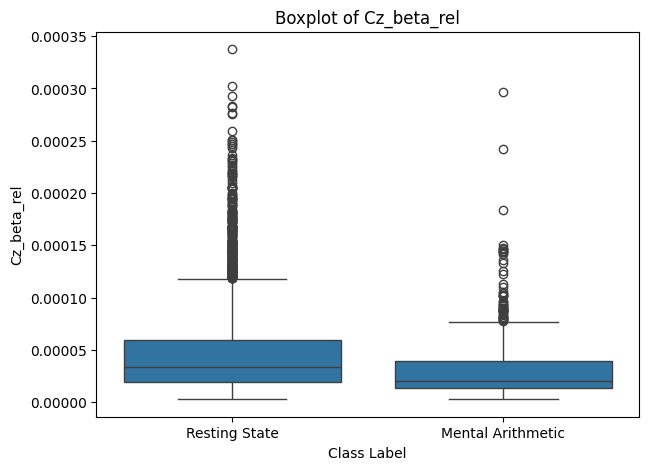

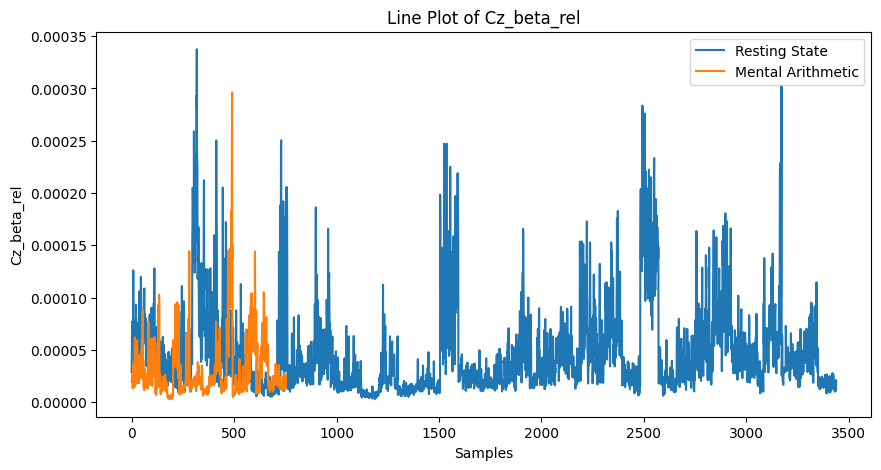

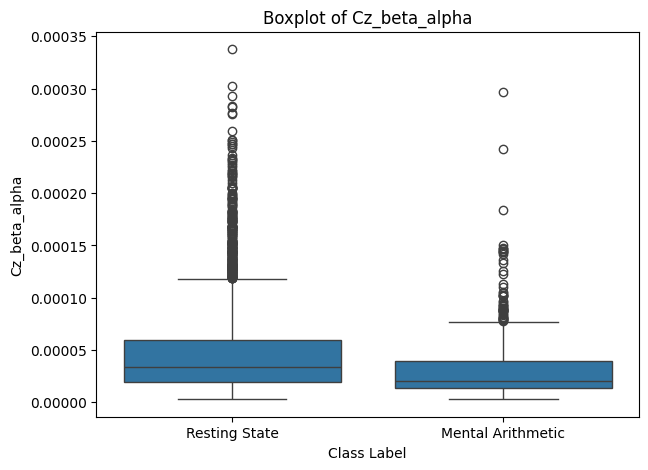

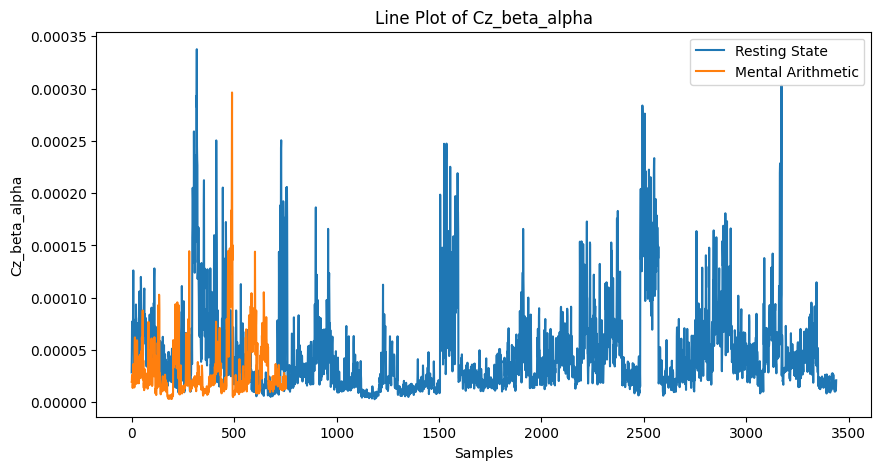

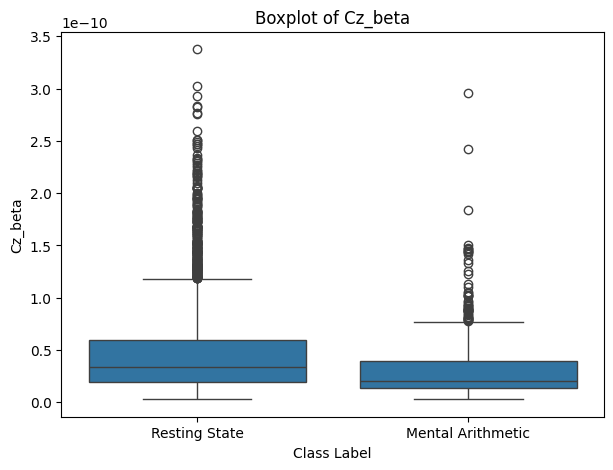

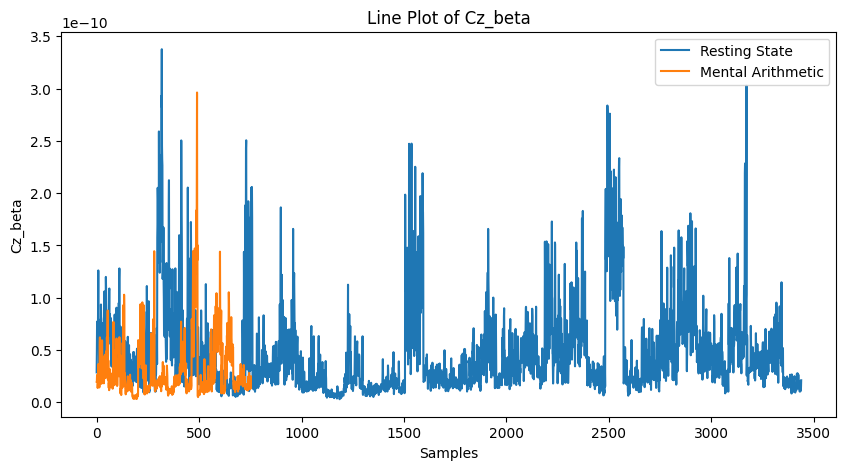

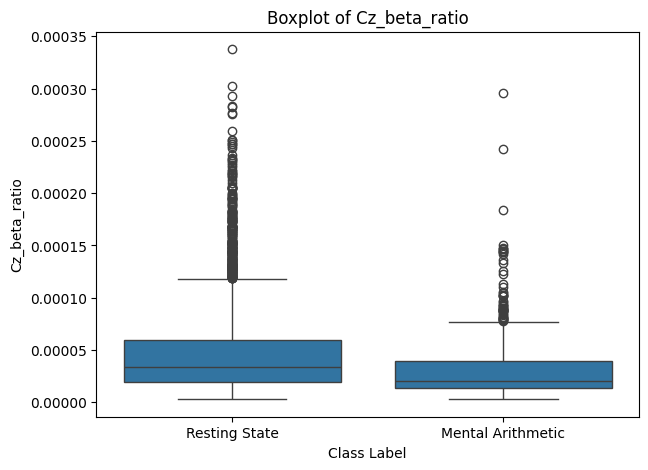

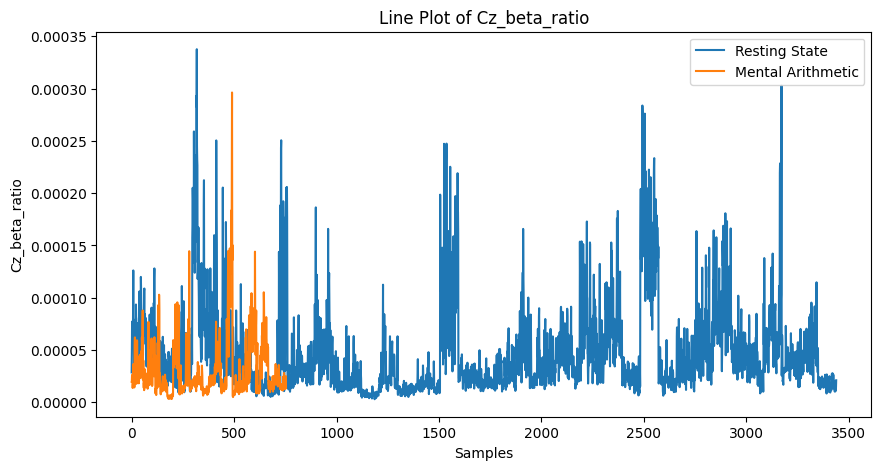

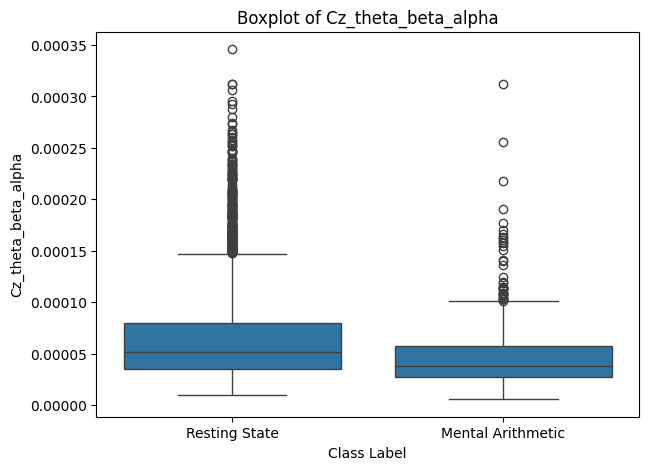

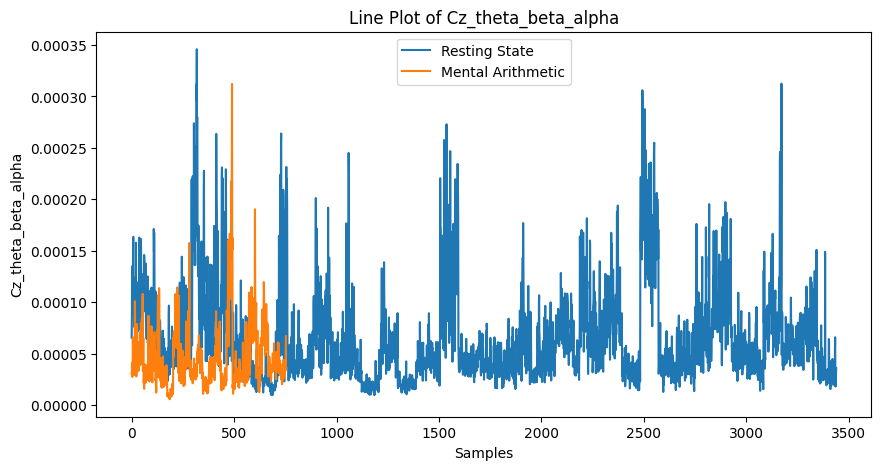

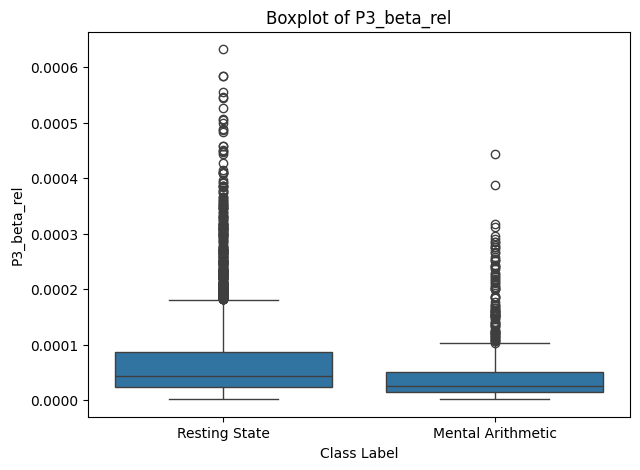

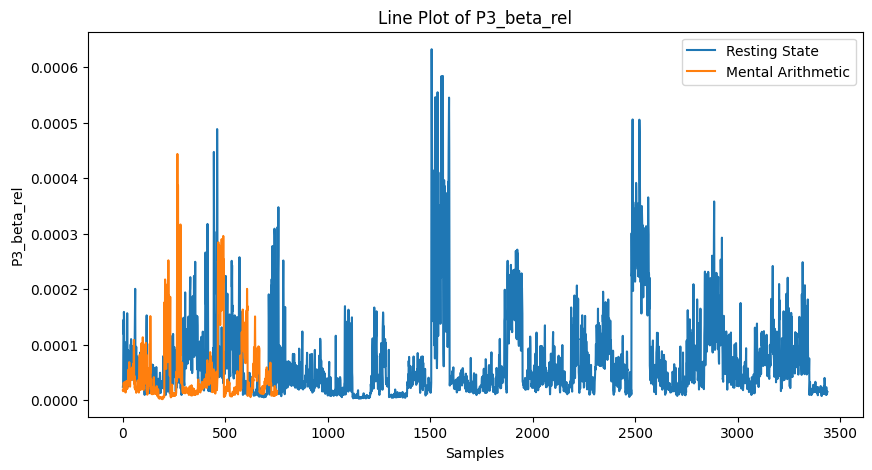

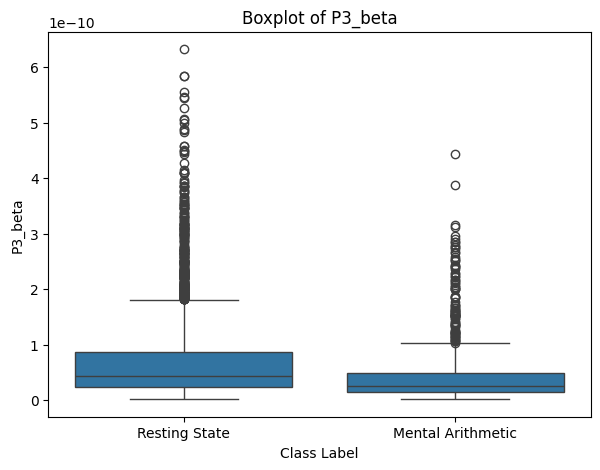

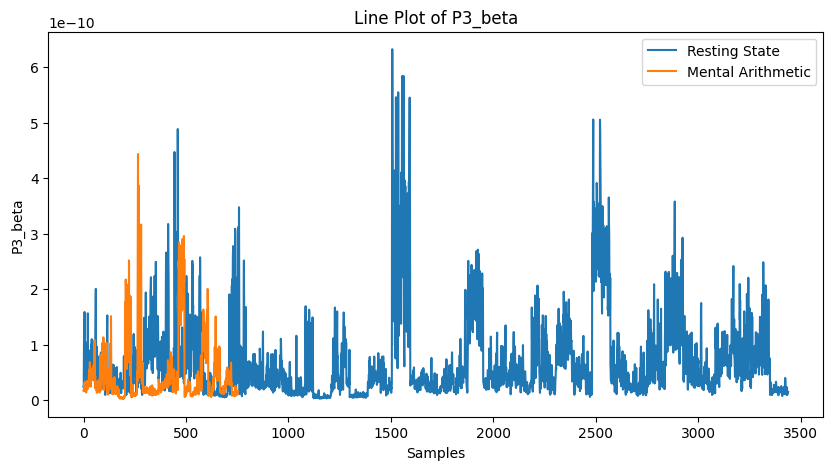

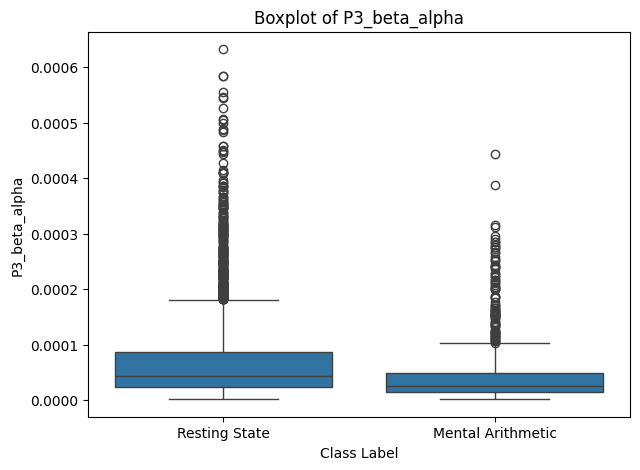

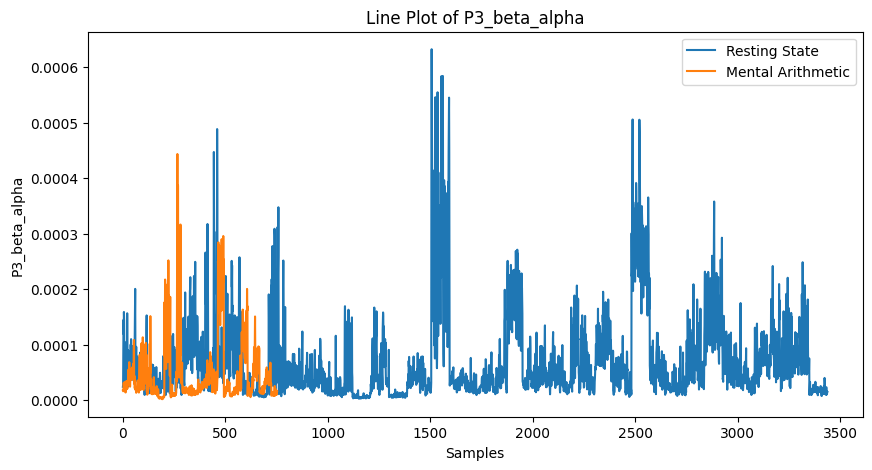

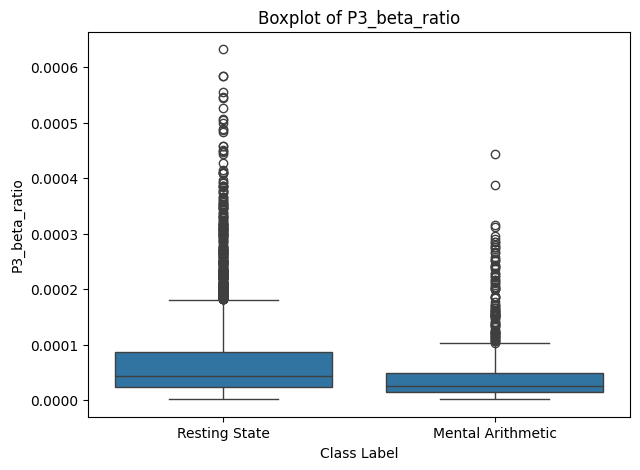

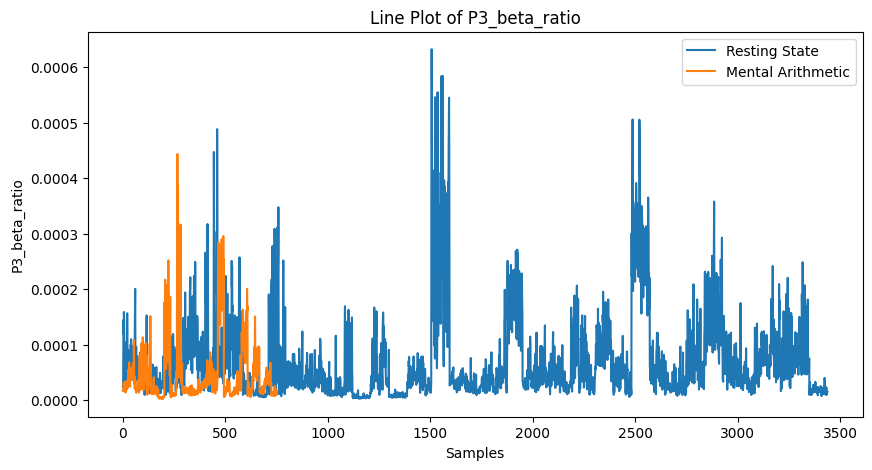

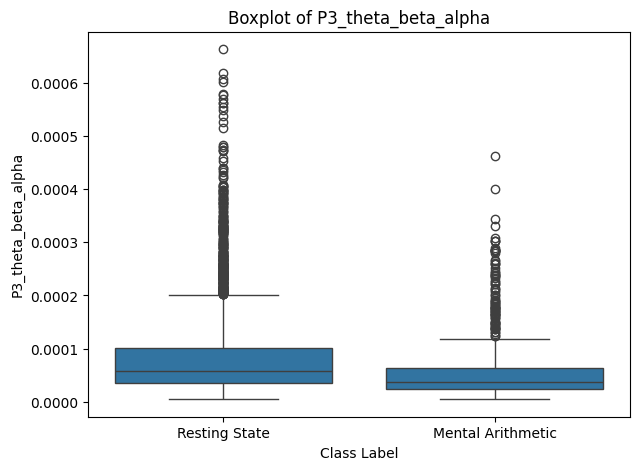

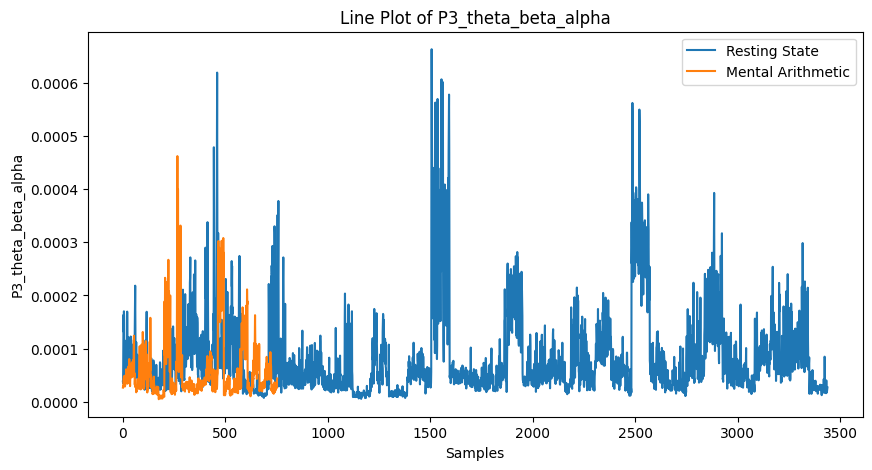

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# GET SIGNIFICANT FEATURES
# ==========================================

significant_features = wilcoxon_df[

    wilcoxon_df['P_Value'] < 0.01
]

# ==========================================
# SORT BY P VALUE
# ==========================================

significant_features = significant_features.sort_values(
    by='P_Value'
)

# ==========================================
# TAKE TOP 10 FEATURES
# ==========================================

top_features = significant_features[
    'Feature'
].head(10).tolist()

# ==========================================
# PLOT BOXPLOTS + LINEPLOTS
# ==========================================

for feature in top_features:

    # ======================================
    # BOXPLOT
    # ======================================

    plt.figure(figsize=(7,5))

    sns.boxplot(

        x='label',
        y=feature,
        data=X_final
    )

    plt.title(f'Boxplot of {feature}')

    plt.xlabel('Class Label')

    plt.ylabel(feature)

    plt.xticks(

        [0,1],

        ['Resting State','Mental Arithmetic']
    )

    plt.show()

    # ======================================
    # LINE PLOT
    # ======================================

    plt.figure(figsize=(10,5))

    # Label 0
    class0 = X_final[
        X_final['label'] == 0
    ][feature].reset_index(drop=True)

    # Label 1
    class1 = X_final[
        X_final['label'] == 1
    ][feature].reset_index(drop=True)

    plt.plot(

        class0,

        label='Resting State'
    )

    plt.plot(

        class1,

        label='Mental Arithmetic'
    )

    plt.title(f'Line Plot of {feature}')

    plt.xlabel('Samples')

    plt.ylabel(feature)

    plt.legend()

    plt.show()

In [ ]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install xgboost
!pip install catboost
!pip install seaborn
!pip install openpyxl
!pip install scikit-learn


TOTAL SIGNIFICANT FEATURES
252


TRAINING MODEL : Logistic Regression

Accuracy  : 0.7580
Precision : 0.4122
Recall    : 0.8079
F1 Score  : 0.5459
ROC AUC   : 0.8381

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.95      0.75      0.84       688
           1       0.41      0.81      0.55       151

    accuracy                           0.76       839
   macro avg       0.68      0.78      0.69       839
weighted avg       0.85      0.76      0.78       839



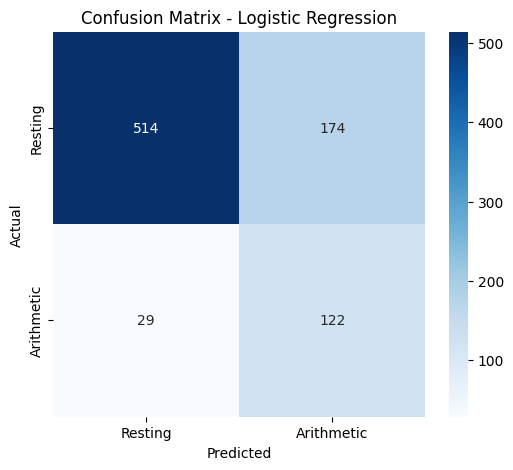

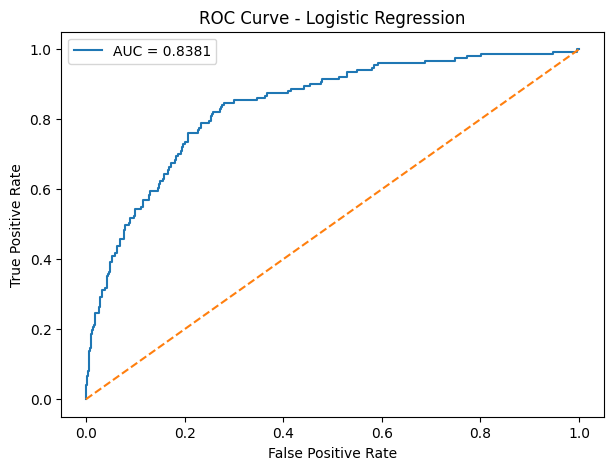



TRAINING MODEL : SVM

Accuracy  : 0.8522
Precision : 0.5542
Recall    : 0.9139
F1 Score  : 0.6900
ROC AUC   : 0.9400

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.98      0.84      0.90       688
           1       0.55      0.91      0.69       151

    accuracy                           0.85       839
   macro avg       0.77      0.88      0.80       839
weighted avg       0.90      0.85      0.86       839



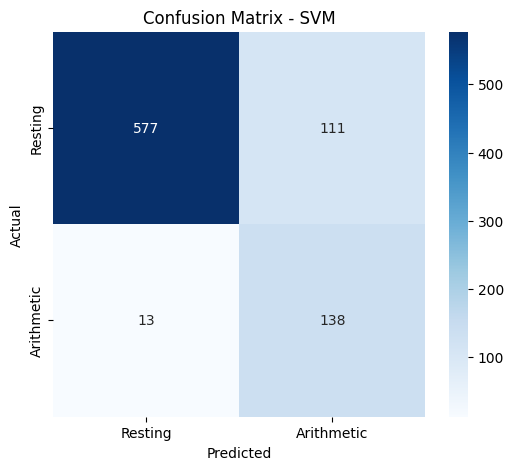

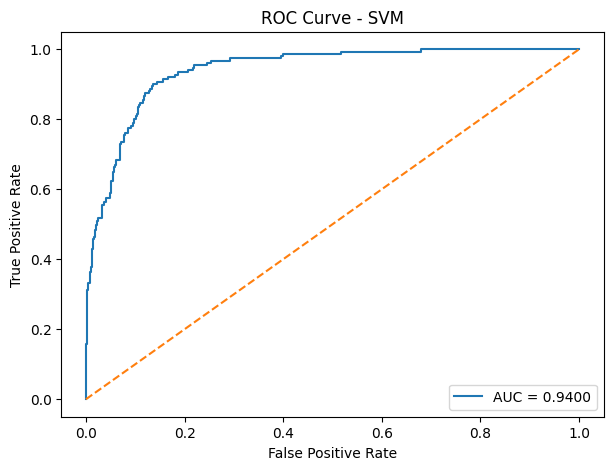



TRAINING MODEL : Decision Tree

Accuracy  : 0.8343
Precision : 0.5423
Recall    : 0.5099
F1 Score  : 0.5256
ROC AUC   : 0.7077

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       688
           1       0.54      0.51      0.53       151

    accuracy                           0.83       839
   macro avg       0.72      0.71      0.71       839
weighted avg       0.83      0.83      0.83       839



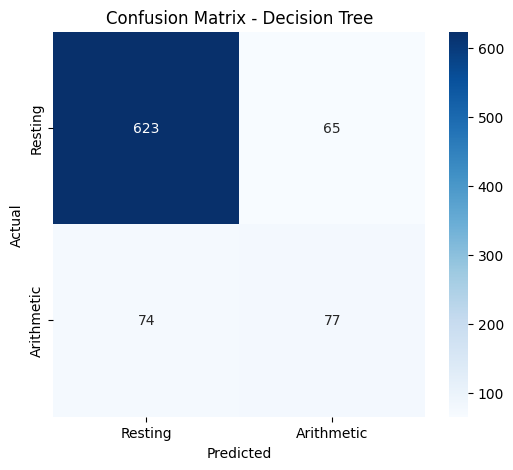

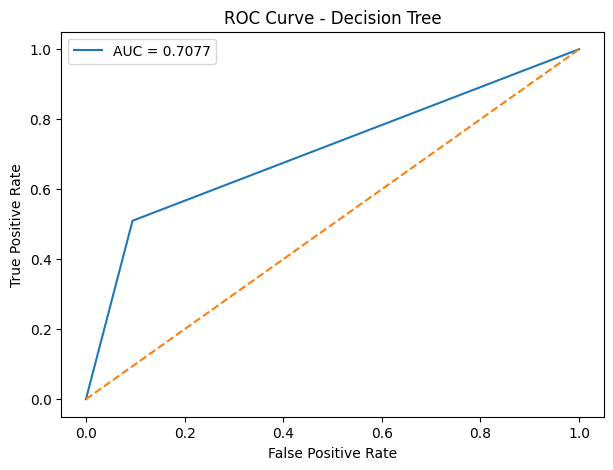



TRAINING MODEL : Random Forest

Accuracy  : 0.8927
Precision : 0.9692
Recall    : 0.4172
F1 Score  : 0.5833
ROC AUC   : 0.9667

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       688
           1       0.97      0.42      0.58       151

    accuracy                           0.89       839
   macro avg       0.93      0.71      0.76       839
weighted avg       0.90      0.89      0.87       839



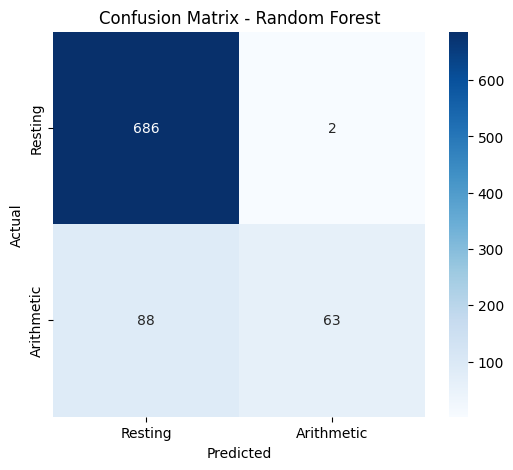

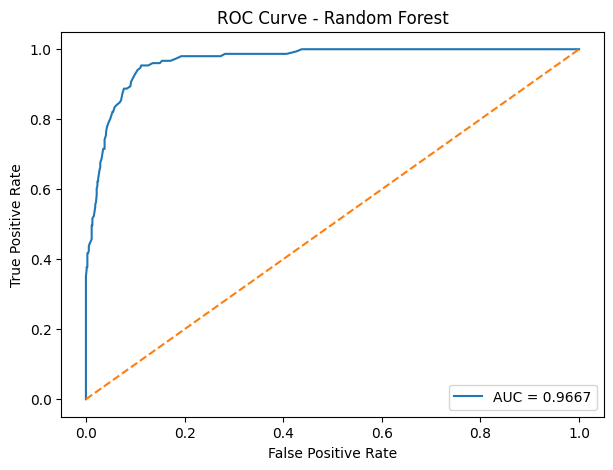



TRAINING MODEL : AdaBoost

Accuracy  : 0.8546
Precision : 0.7231
Recall    : 0.3113
F1 Score  : 0.4352
ROC AUC   : 0.8693

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       688
           1       0.72      0.31      0.44       151

    accuracy                           0.85       839
   macro avg       0.79      0.64      0.68       839
weighted avg       0.84      0.85      0.83       839



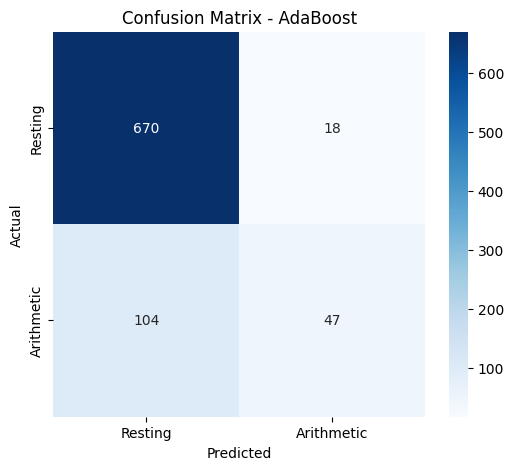

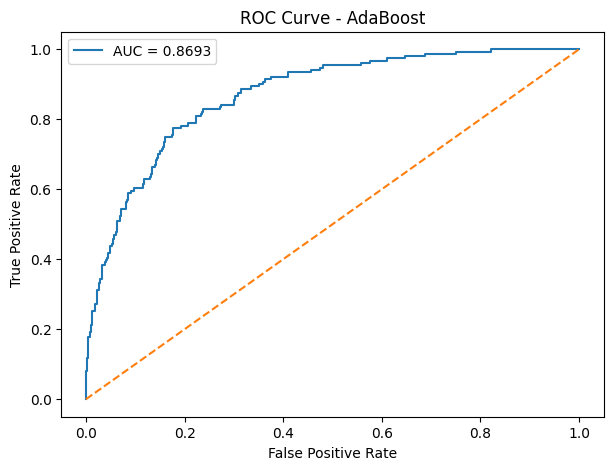



TRAINING MODEL : XGBoost

Accuracy  : 0.9297
Precision : 0.9423
Recall    : 0.6490
F1 Score  : 0.7686
ROC AUC   : 0.9751

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       688
           1       0.94      0.65      0.77       151

    accuracy                           0.93       839
   macro avg       0.94      0.82      0.86       839
weighted avg       0.93      0.93      0.92       839



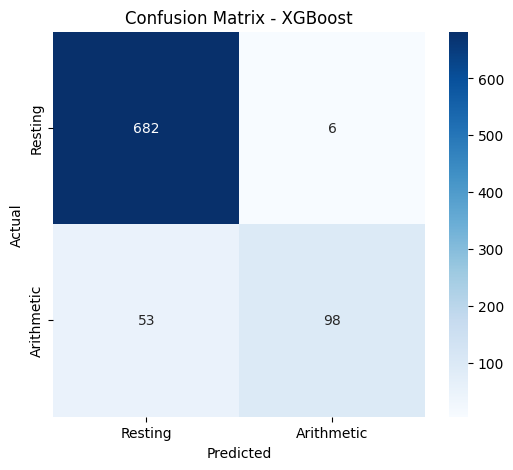

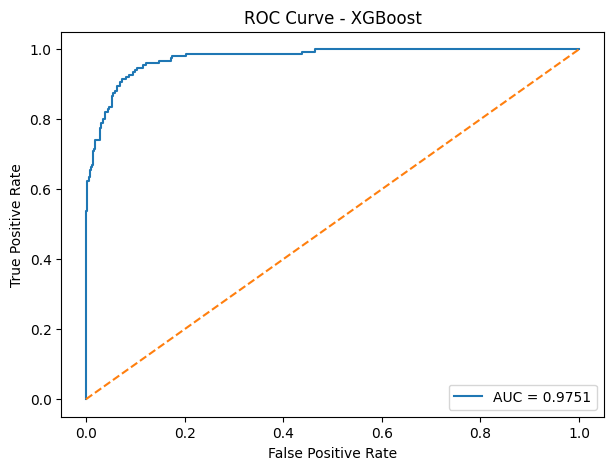



TRAINING MODEL : CatBoost

Accuracy  : 0.9058
Precision : 0.9286
Recall    : 0.5166
F1 Score  : 0.6638
ROC AUC   : 0.9682

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.90      0.99      0.95       688
           1       0.93      0.52      0.66       151

    accuracy                           0.91       839
   macro avg       0.92      0.75      0.80       839
weighted avg       0.91      0.91      0.89       839



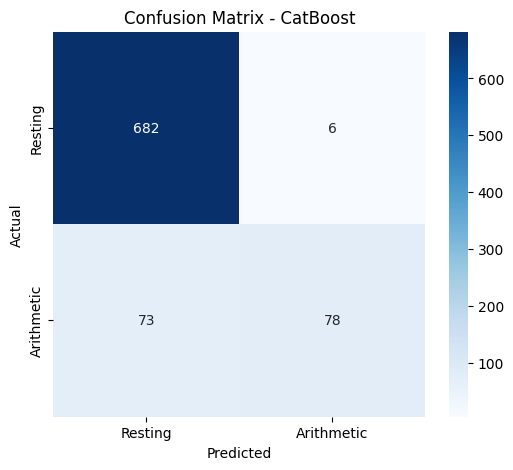

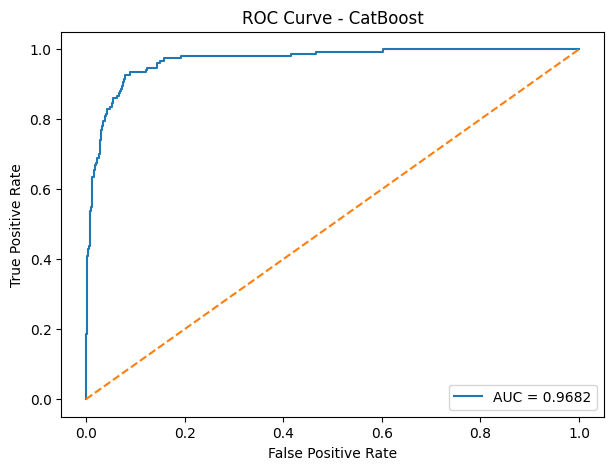



TRAINING MODEL : Stacking

Accuracy  : 0.9428
Precision : 0.8815
Recall    : 0.7881
F1 Score  : 0.8322
ROC AUC   : 0.9773

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       688
           1       0.88      0.79      0.83       151

    accuracy                           0.94       839
   macro avg       0.92      0.88      0.90       839
weighted avg       0.94      0.94      0.94       839



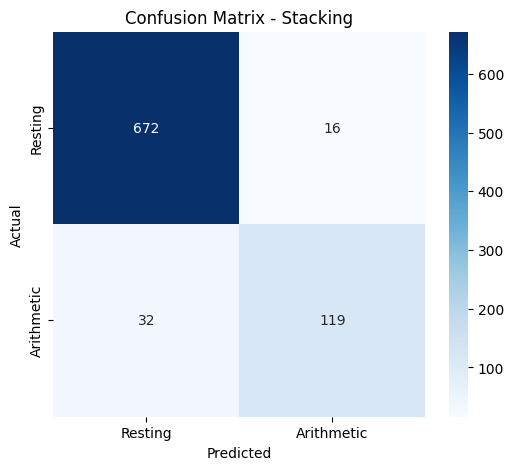

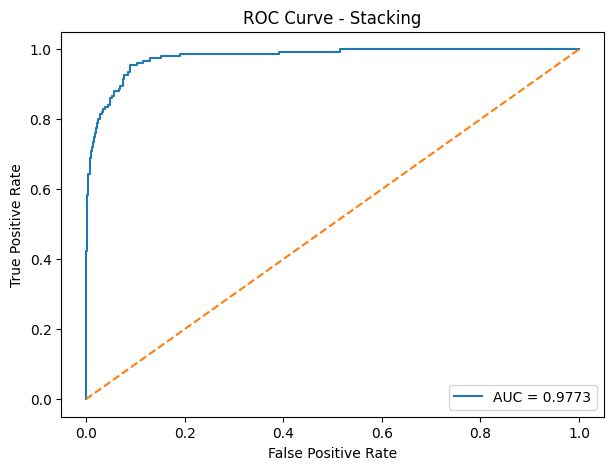



FINAL MODEL COMPARISON

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
7             Stacking    0.9428     0.8815  0.7881    0.8322   0.9773
5              XGBoost    0.9297     0.9423  0.6490    0.7686   0.9751
6             CatBoost    0.9058     0.9286  0.5166    0.6638   0.9682
3        Random Forest    0.8927     0.9692  0.4172    0.5833   0.9667
4             AdaBoost    0.8546     0.7231  0.3113    0.4352   0.8693
1                  SVM    0.8522     0.5542  0.9139    0.6900   0.9400
2        Decision Tree    0.8343     0.5423  0.5099    0.5256   0.7077
0  Logistic Regression    0.7580     0.4122  0.8079    0.5459   0.8381

TOP SIGNIFICANT FEATURES

Cz_beta_rel
Cz_beta_alpha
Cz_beta
Cz_beta_ratio
Cz_theta_beta_alpha
P3_beta_rel
P3_beta
P3_beta_alpha
P3_beta_ratio
P3_theta_beta_alpha
Fp1_alpha
Fp1_alpha_delta
Fp1_alpha_rel
F4_beta_minus_alpha
C3_beta_minus_alpha


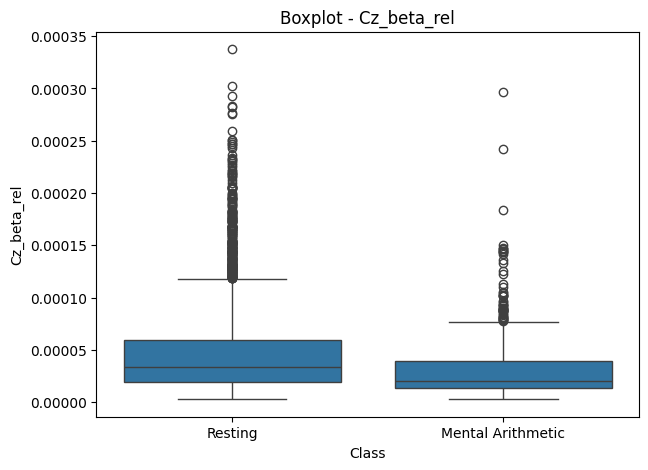

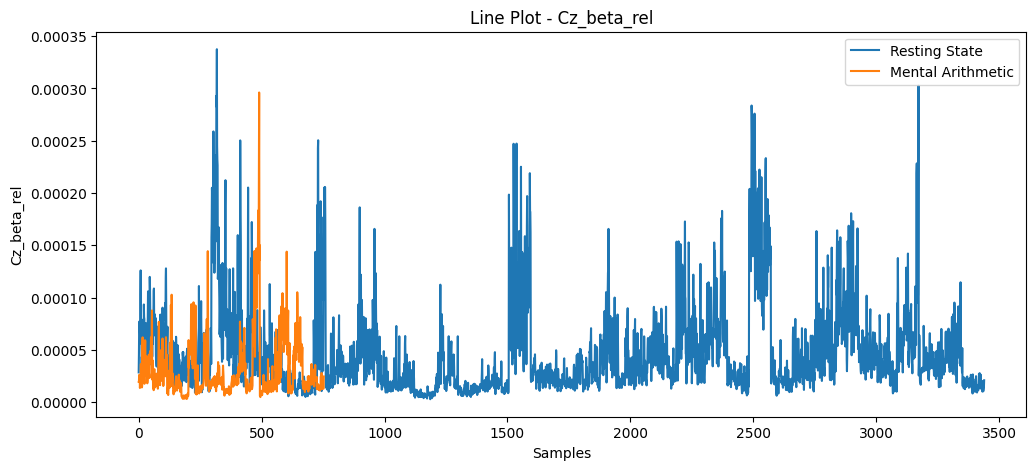

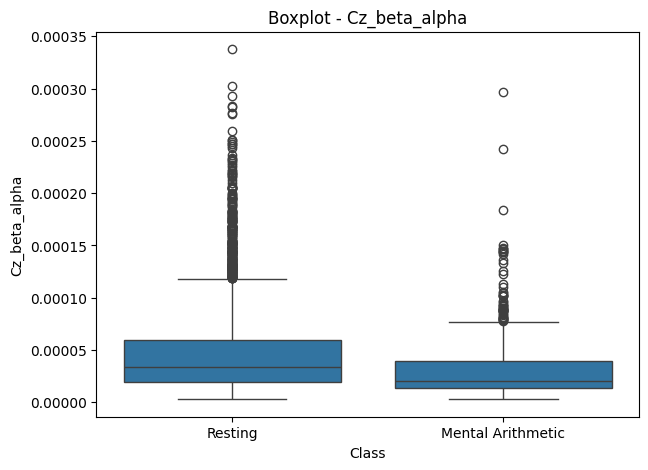

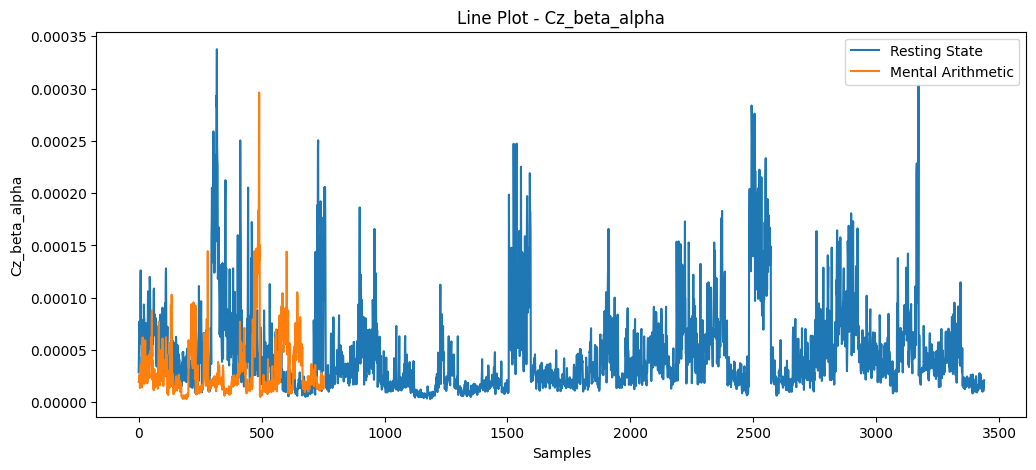

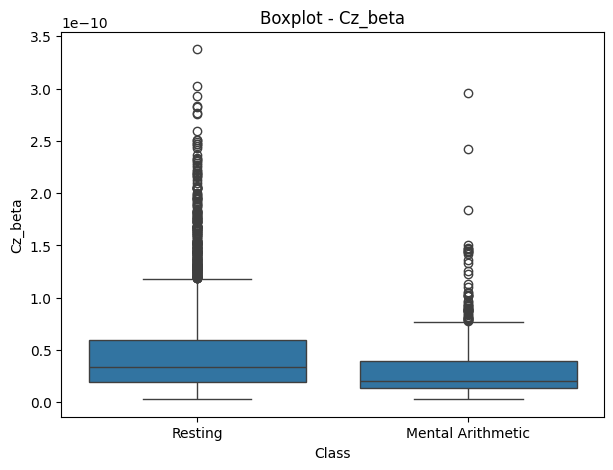

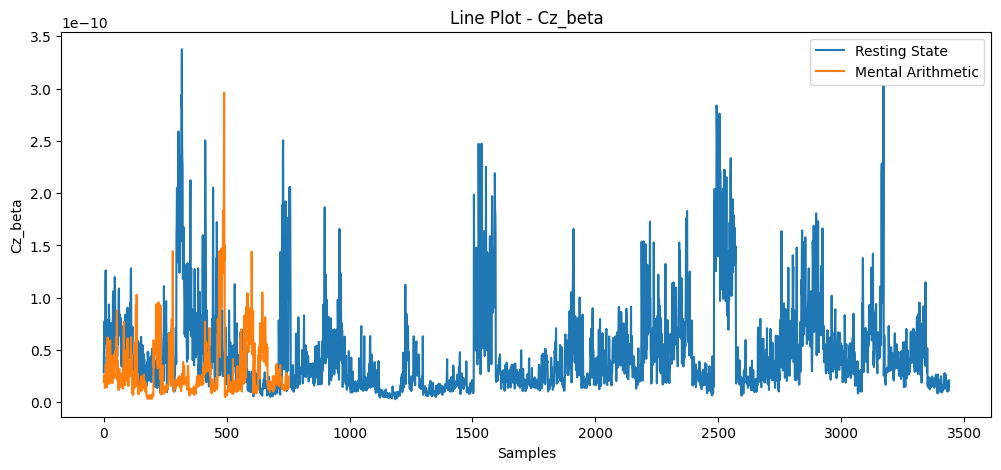

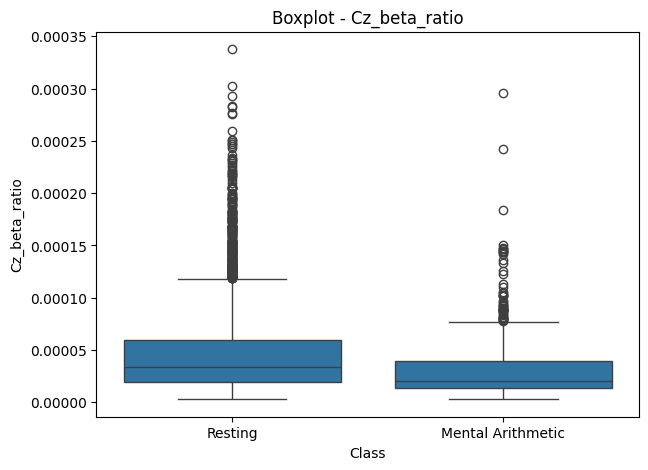

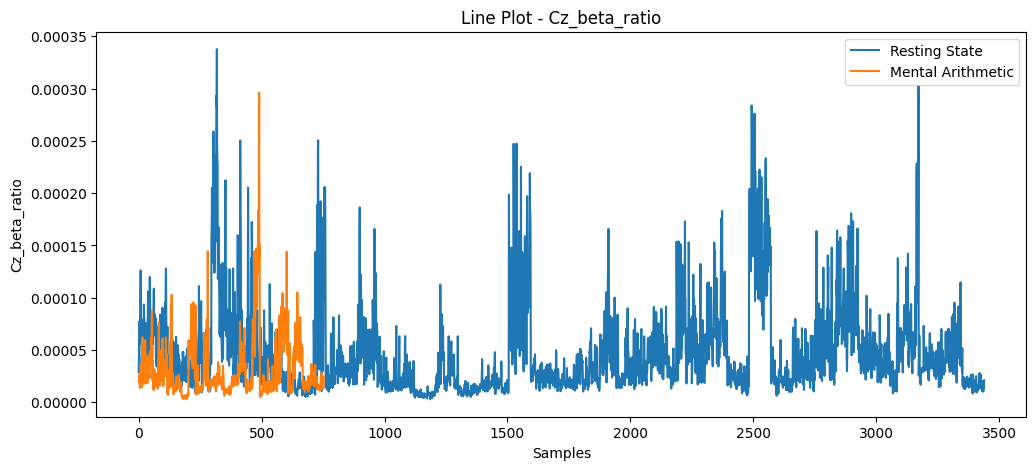

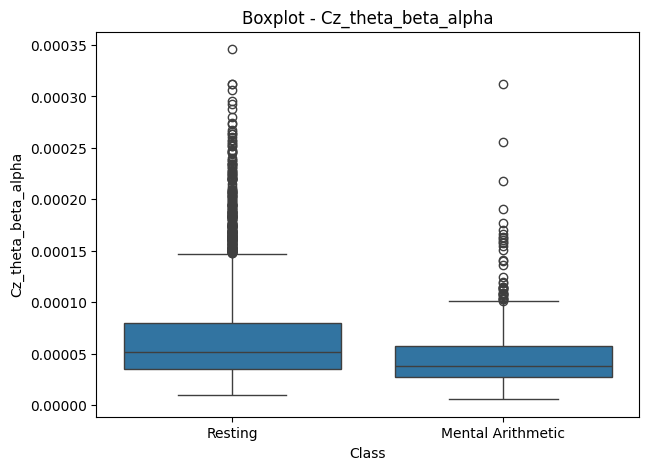

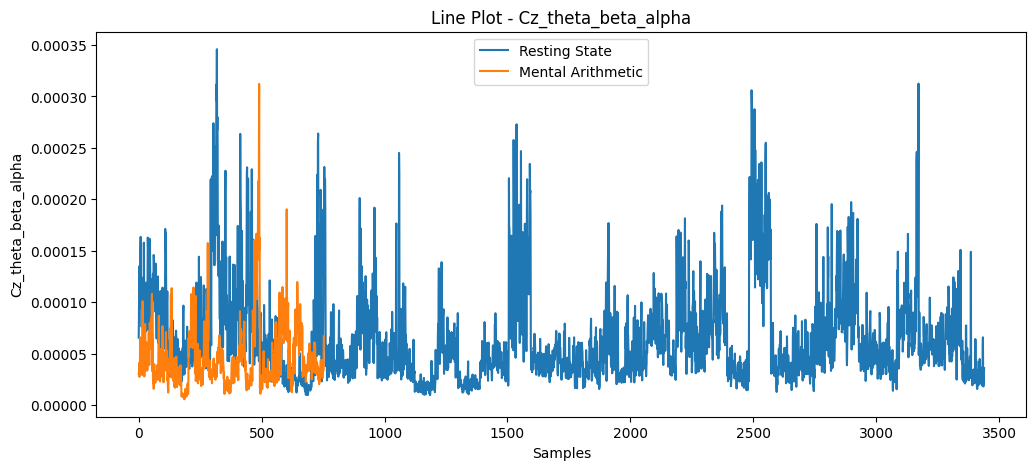

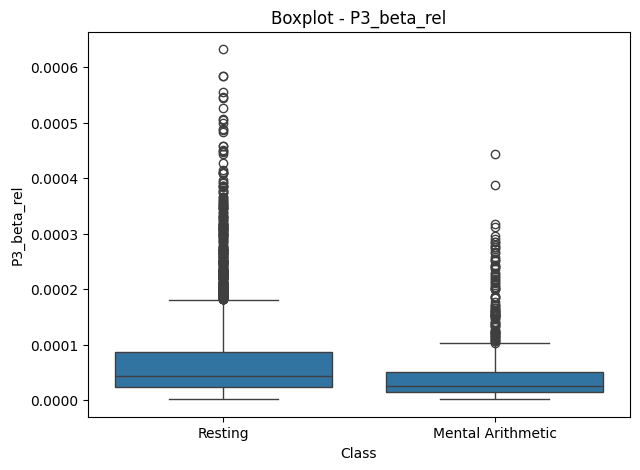

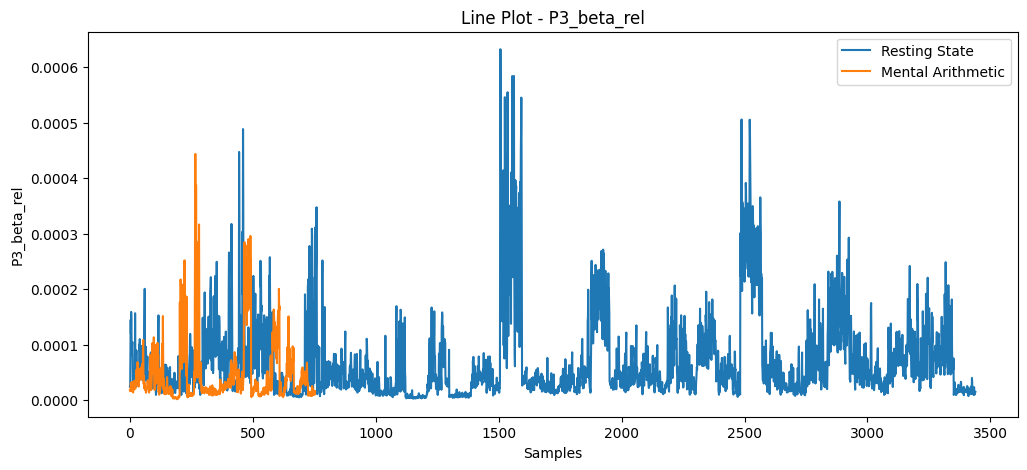

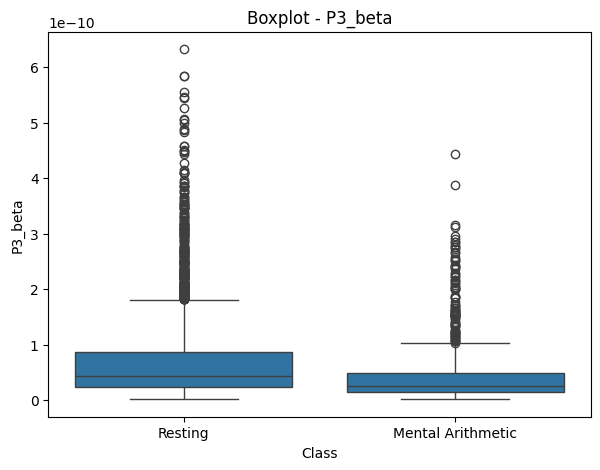

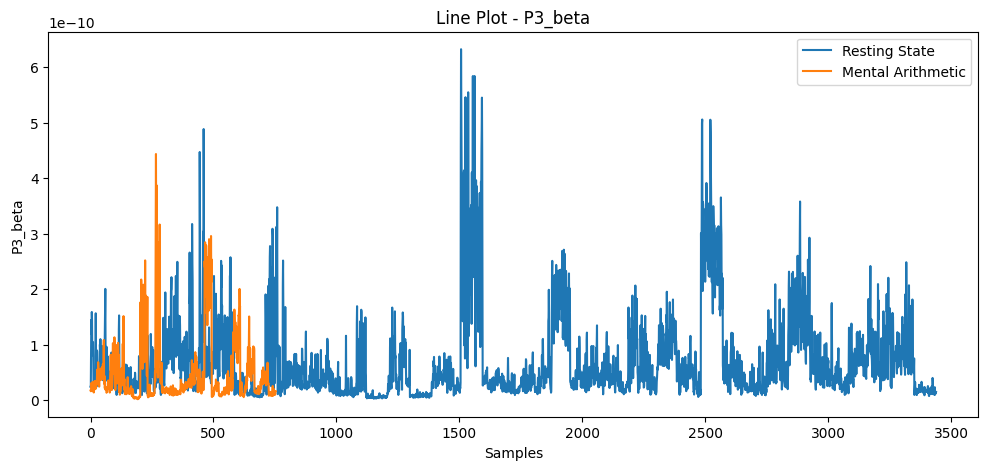

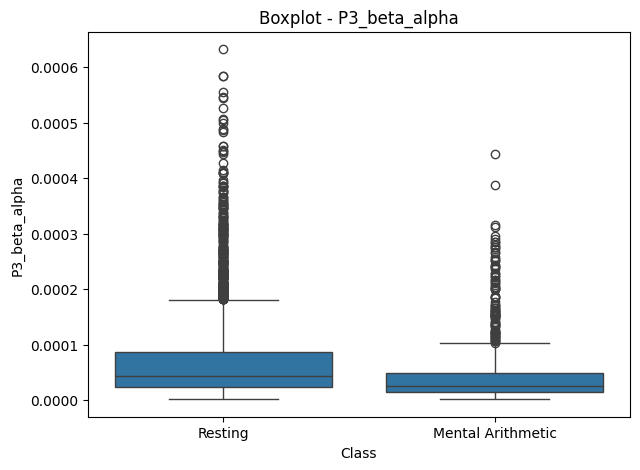

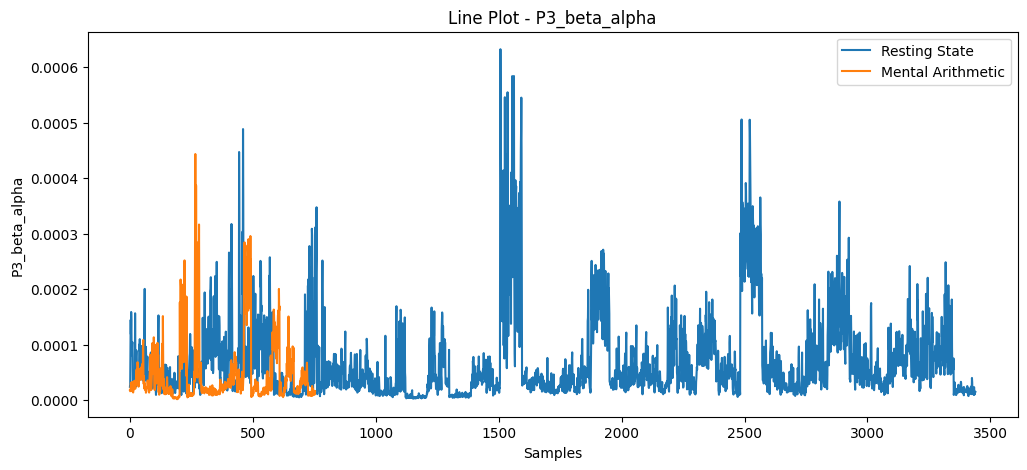

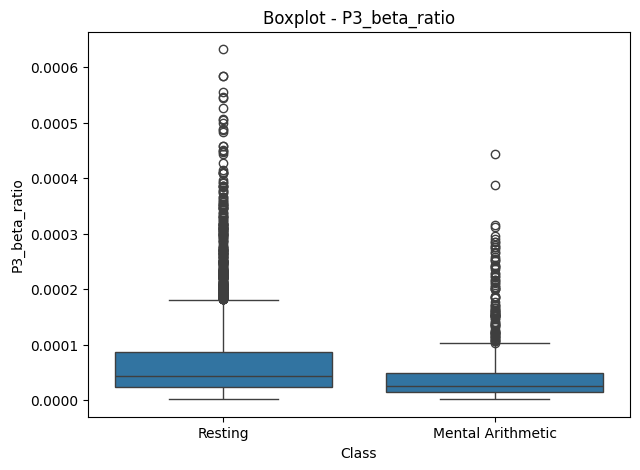

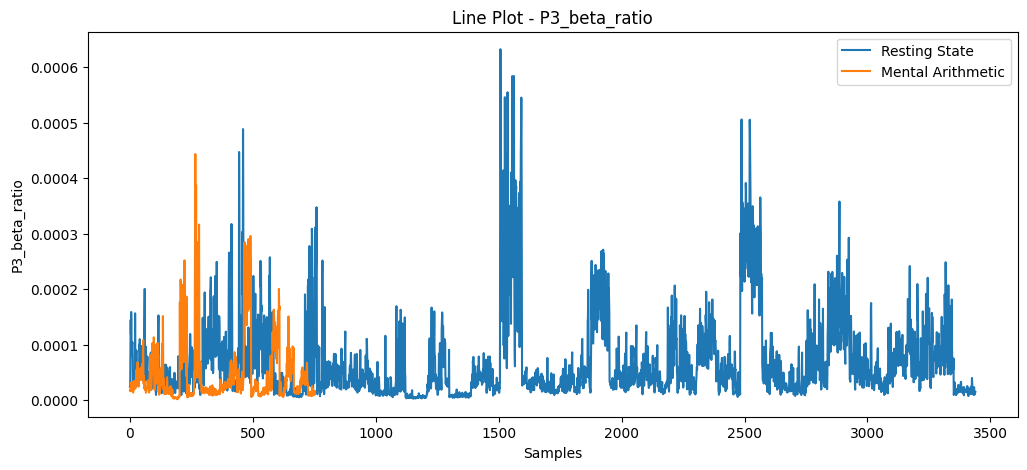

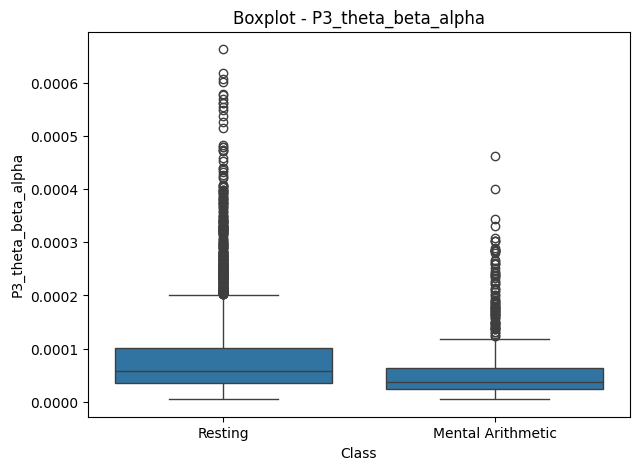

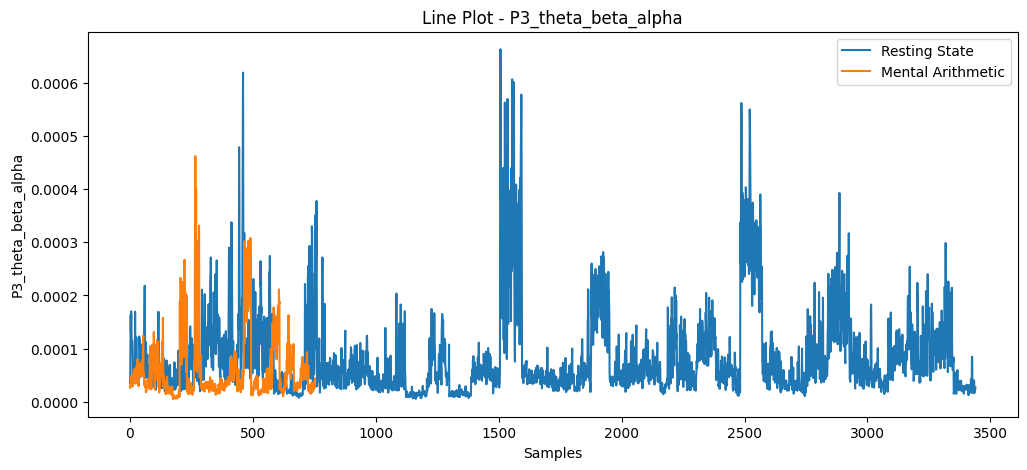

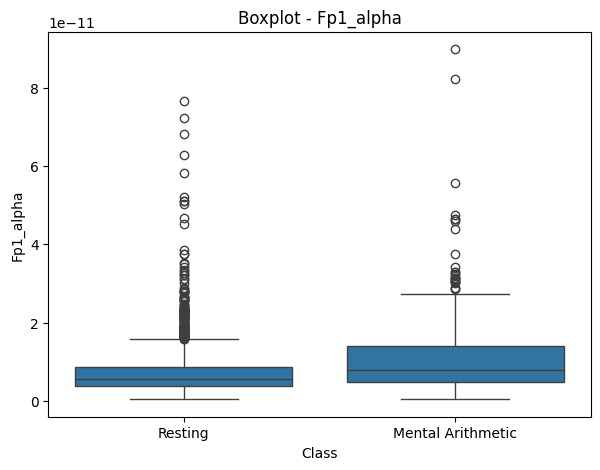

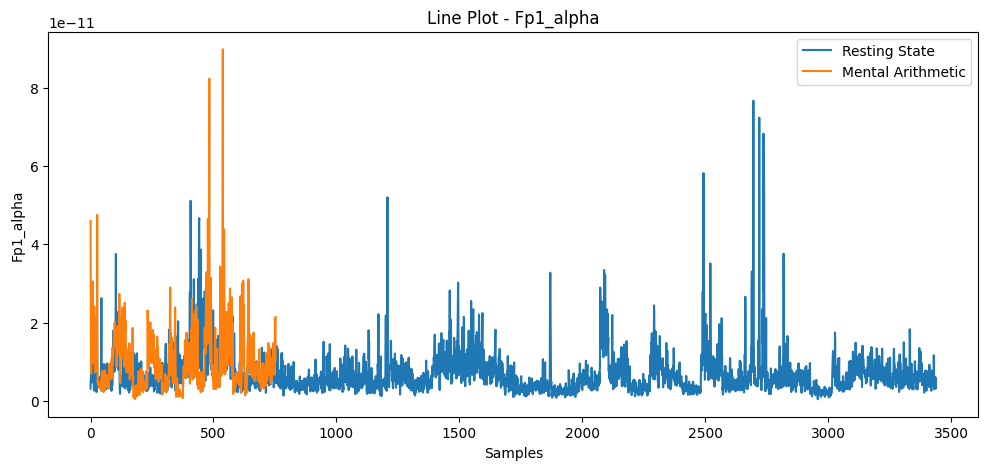

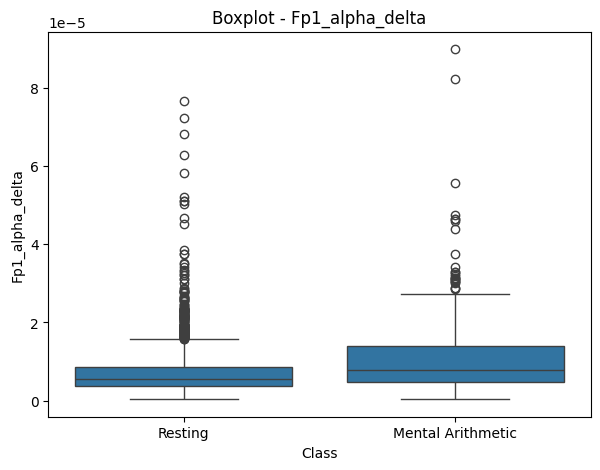

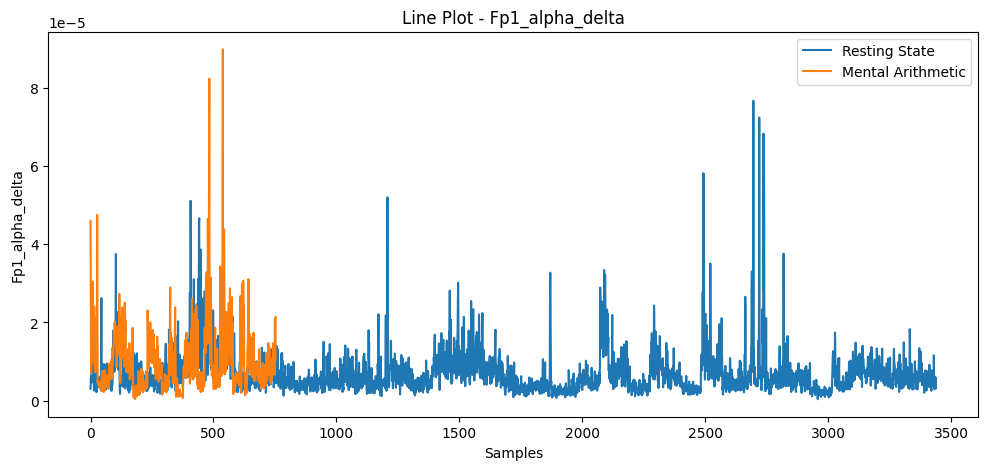

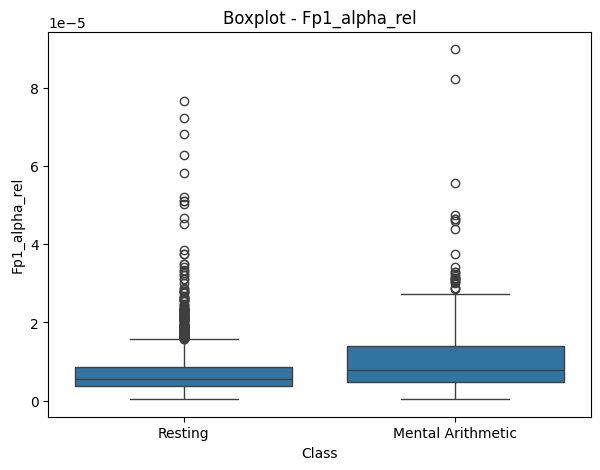

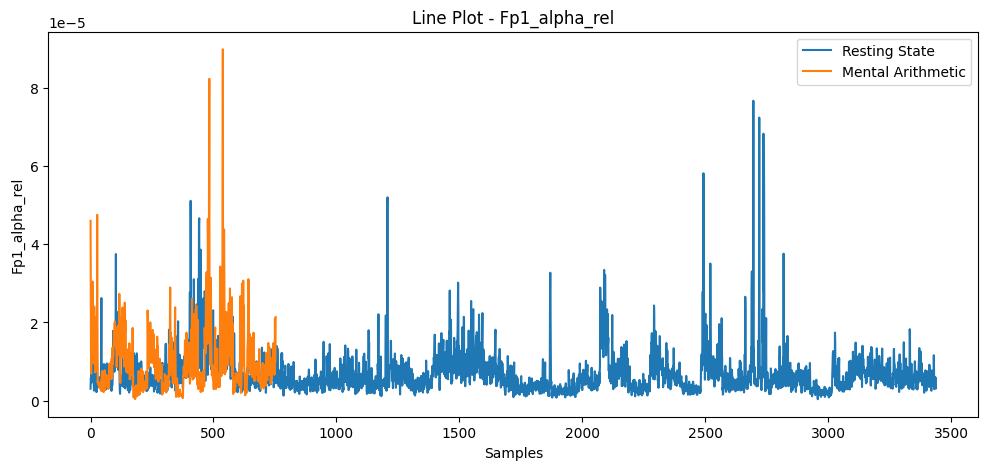

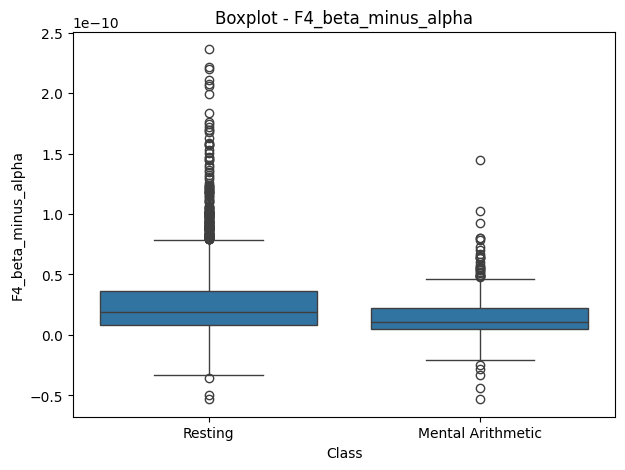

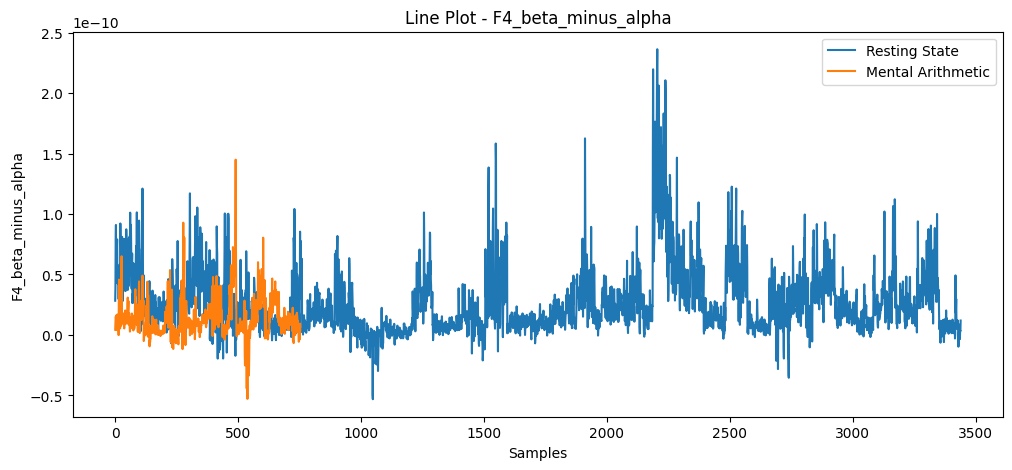

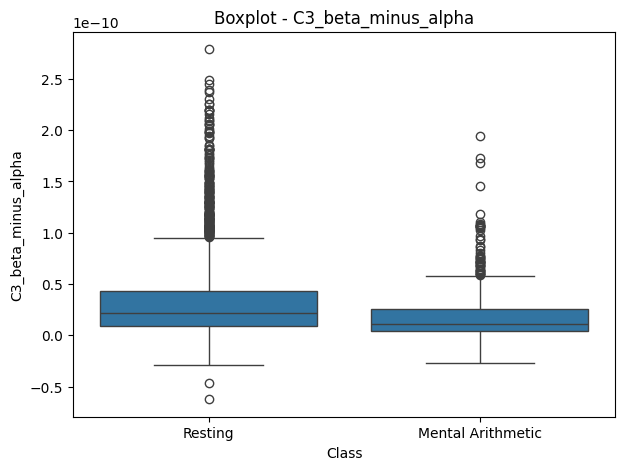

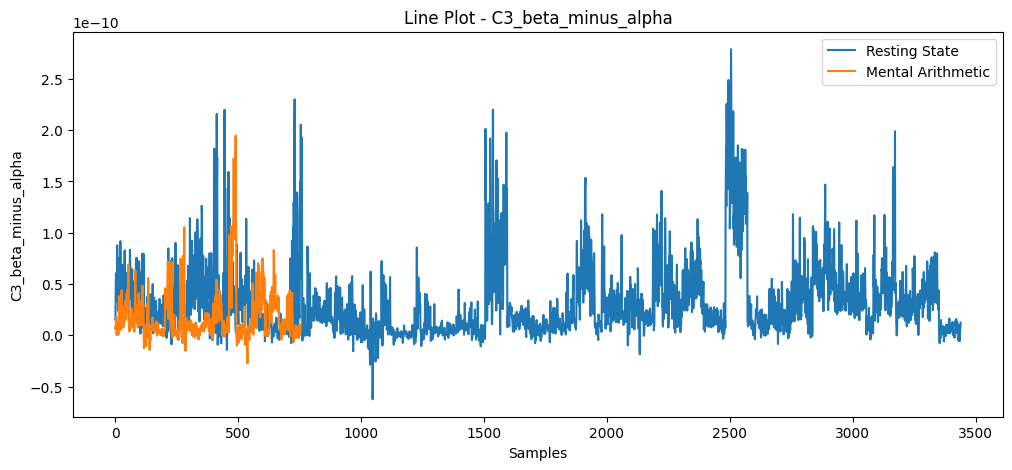

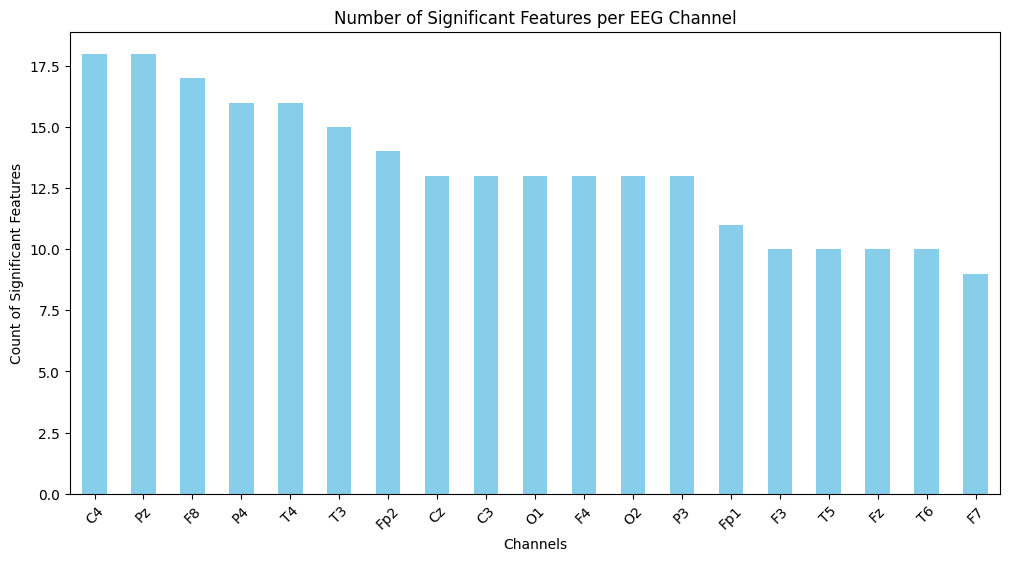

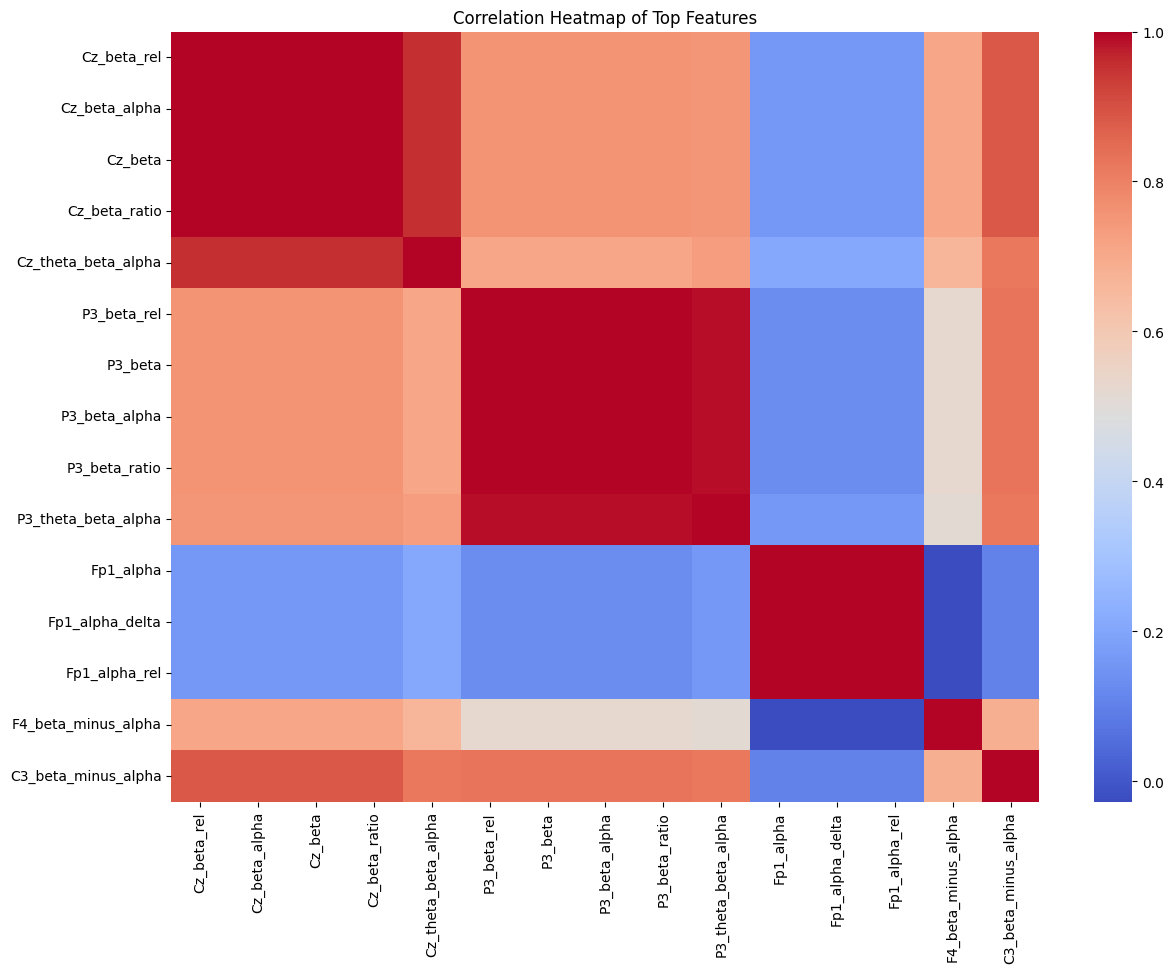

In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ============================================================
# LOAD DATA
# ============================================================

# X_final should contain:
# all extracted features + label column

# Example:
# X_final = pd.read_excel("final_dataset.xlsx")

# ============================================================
# SELECT SIGNIFICANT FEATURES
# ============================================================

significant_df = wilcoxon_df[
    wilcoxon_df['P_Value'] < 0.01
]

# ============================================================
# SORT FEATURES BY P VALUE
# ============================================================

significant_df = significant_df.sort_values(
    by='P_Value'
)

# ============================================================
# GET ALL SIGNIFICANT FEATURES
# ============================================================

significant_features = significant_df[
    'Feature'
].tolist()

print("\n====================================")
print("TOTAL SIGNIFICANT FEATURES")
print("====================================")

print(len(significant_features))

# ============================================================
# PREPARE DATA
# ============================================================

X = X_final[significant_features]

y = X_final['label']

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ============================================================
# DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(

        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ),

    "SVM": SVC(

        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(

        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(

        n_estimators=200,

        class_weight='balanced',

        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(

        n_estimators=200,

        random_state=42
    ),

    "XGBoost": XGBClassifier(

        n_estimators=200,

        learning_rate=0.05,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        eval_metric='logloss',

        random_state=42
    ),

    "CatBoost": CatBoostClassifier(

        iterations=200,

        learning_rate=0.05,

        depth=6,

        verbose=0,

        random_state=42
    )
}

# ============================================================
# STACKING CLASSIFIER
# ============================================================

estimators = [

    ('rf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )),

    ('xgb', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )),

    ('cat', CatBoostClassifier(
        verbose=0,
        random_state=42
    ))
]

stacking_model = StackingClassifier(

    estimators=estimators,

    final_estimator=LogisticRegression(),

    passthrough=False
)

models["Stacking"] = stacking_model

# ============================================================
# STORE RESULTS
# ============================================================

results = []

# ============================================================
# TRAIN MODELS
# ============================================================

for name, model in models.items():

    print("\n\n=================================================")
    print(f"TRAINING MODEL : {name}")
    print("=================================================")

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    model.fit(X_train_scaled, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================

    y_pred = model.predict(X_test_scaled)

    # ========================================================
    # PROBABILITIES
    # ========================================================

    y_probs = model.predict_proba(X_test_scaled)[:,1]

    # ========================================================
    # METRICS
    # ========================================================

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(y_test, y_pred)

    rec = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_probs)

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append([

        name,

        round(acc,4),

        round(prec,4),

        round(rec,4),

        round(f1,4),

        round(auc,4)
    ])

    # ========================================================
    # PRINT METRICS
    # ========================================================

    print(f"\nAccuracy  : {acc:.4f}")

    print(f"Precision : {prec:.4f}")

    print(f"Recall    : {rec:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print(f"ROC AUC   : {auc:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nCLASSIFICATION REPORT\n")

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='Blues',

        xticklabels=['Resting','Arithmetic'],

        yticklabels=['Resting','Arithmetic']
    )

    plt.title(f'Confusion Matrix - {name}')

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probs
    )

    plt.figure(figsize=(7,5))

    plt.plot(

        fpr,
        tpr,

        label=f'AUC = {auc:.4f}'
    )

    plt.plot([0,1],[0,1],'--')

    plt.xlabel('False Positive Rate')

    plt.ylabel('True Positive Rate')

    plt.title(f'ROC Curve - {name}')

    plt.legend()

    plt.show()

# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(

    results,

    columns=[

        'Model',

        'Accuracy',

        'Precision',

        'Recall',

        'F1 Score',

        'ROC AUC'
    ]
)

# ============================================================
# SORT RESULTS
# ============================================================

results_df = results_df.sort_values(

    by='Accuracy',

    ascending=False
)

# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n\n=================================================")
print("FINAL MODEL COMPARISON")
print("=================================================\n")

print(results_df)

# ============================================================
# VISUALIZATION OF TOP FEATURES
# ============================================================

print("\n========================================")
print("TOP SIGNIFICANT FEATURES")
print("========================================\n")

top_features = significant_df[
    'Feature'
].head(15).tolist()

for feature in top_features:

    print(feature)

# ============================================================
# BOXPLOTS + LINEPLOTS
# ============================================================

for feature in top_features:

    # ========================================================
    # BOXPLOT
    # ========================================================

    plt.figure(figsize=(7,5))

    sns.boxplot(

        x='label',

        y=feature,

        data=X_final
    )

    plt.title(f'Boxplot - {feature}')

    plt.xlabel('Class')

    plt.ylabel(feature)

    plt.xticks(

        [0,1],

        ['Resting','Mental Arithmetic']
    )

    plt.show()

    # ========================================================
    # LINE PLOT
    # ========================================================

    plt.figure(figsize=(12,5))

    class0 = X_final[
        X_final['label'] == 0
    ][feature].reset_index(drop=True)

    class1 = X_final[
        X_final['label'] == 1
    ][feature].reset_index(drop=True)

    plt.plot(

        class0,

        label='Resting State'
    )

    plt.plot(

        class1,

        label='Mental Arithmetic'
    )

    plt.title(f'Line Plot - {feature}')

    plt.xlabel('Samples')

    plt.ylabel(feature)

    plt.legend()

    plt.show()

# ============================================================
# CHANNEL SIGNIFICANCE BAR GRAPH
# ============================================================

plt.figure(figsize=(12,6))

channel_counts.plot(

    kind='bar',

    color='skyblue'
)

plt.title(

    'Number of Significant Features per EEG Channel'
)

plt.xlabel('Channels')

plt.ylabel('Count of Significant Features')

plt.xticks(rotation=45)

plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(14,10))

corr = X_final[top_features].corr()

sns.heatmap(

    corr,

    cmap='coolwarm',

    annot=False
)

plt.title('Correlation Heatmap of Top Features')

plt.show()

In [ ]:
for ch in channels:

    print("\n==============================")
    print(f"PROCESSING CHANNEL: {ch}")
    print("==============================")

    # =====================================
    # SELECT CHANNEL FEATURES
    # =====================================

    ch_features = [
        col for col in X_final.columns
        if col.startswith(ch + '_')
    ]

    X = X_final[ch_features]

    y = X_final['label']

    # =====================================
    # CLEAN DATA
    # =====================================

    X = X.replace([np.inf, -np.inf], np.nan)

    X = X.fillna(0)

    # =====================================
    # TRAIN TEST SPLIT
    # =====================================

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # =====================================
    # SCALING
    # =====================================

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    # =====================================
    # FEATURE SELECTION
    # =====================================

    selector = SelectKBest(
        mutual_info_classif,
        k=10
    )

    X_train = selector.fit_transform(X_train, y_train)

    X_test = selector.transform(X_test)

    # =====================================
    # XGBOOST MODEL
    # =====================================

    model = XGBClassifier(
        objective='binary:logistic',

        n_estimators=300,

        max_depth=5,

        learning_rate=0.03,

        subsample=0.8,

        colsample_bytree=0.8,

        scale_pos_weight=3,

        eval_metric='logloss',

        random_state=42
    )

    # =====================================
    # HYPERPARAMETER TUNING
    # =====================================

    param_grid = {

        'n_estimators': [100, 200, 300],

        'max_depth': [3, 4, 5, 6],

        'learning_rate': [0.01, 0.03, 0.05],

        'subsample': [0.7, 0.8, 1.0],

        'colsample_bytree': [0.7, 0.8, 1.0]
    }

    random_search = RandomizedSearchCV(

        estimator=model,

        param_distributions=param_grid,

        n_iter=10,

        scoring='f1',

        cv=3,

        verbose=0,

        random_state=42,

        n_jobs=-1
    )

    # =====================================
    # TRAIN MODEL
    # =====================================

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_

    # =====================================
    # PREDICTIONS
    # =====================================

    y_pred = best_model.predict(X_test)

    # =====================================
    # METRICS
    # =====================================

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(y_test, y_pred)

    rec = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # =====================================
    # PRINT RESULTS
    # =====================================

    print(f"Accuracy : {acc:.4f}")

    print(f"Precision: {prec:.4f}")

    print(f"Recall   : {rec:.4f}")

    print(f"F1 Score : {f1:.4f}")

    # =====================================
    # SAVE RESULTS
    # =====================================

    results.append([
        ch,
        acc,
        prec,
        rec,
        f1
    ])


PROCESSING CHANNEL: Fp1
Accuracy : 0.7271
Precision: 0.4615
Recall   : 0.5742
F1 Score : 0.5117

PROCESSING CHANNEL: Fp2
Accuracy : 0.5983
Precision: 0.3325
Recall   : 0.6077
F1 Score : 0.4298

PROCESSING CHANNEL: F3
Accuracy : 0.5673
Precision: 0.3056
Recall   : 0.5789
F1 Score : 0.4000

PROCESSING CHANNEL: F4
Accuracy : 0.6031
Precision: 0.3324
Recall   : 0.5885
F1 Score : 0.4249

PROCESSING CHANNEL: F7
Accuracy : 0.5614
Precision: 0.3138
Recall   : 0.6411
F1 Score : 0.4214

PROCESSING CHANNEL: F8
Accuracy : 0.6186
Precision: 0.3437
Recall   : 0.5837
F1 Score : 0.4326

PROCESSING CHANNEL: T3
Accuracy : 0.6067
Precision: 0.3412
Recall   : 0.6220
F1 Score : 0.4407

PROCESSING CHANNEL: T4
Accuracy : 0.5662
Precision: 0.3159
Recall   : 0.6364
F1 Score : 0.4222

PROCESSING CHANNEL: C3
Accuracy : 0.6031
Precision: 0.3155
Recall   : 0.5072
F1 Score : 0.3890

PROCESSING CHANNEL: C4
Accuracy : 0.6377
Precision: 0.3453
Recall   : 0.5072
F1 Score : 0.4109

PROCESSING CHANNEL: T5
Accuracy : 0.5

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Channel',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ]
)

In [ ]:
results_df = results_df.sort_values(
    by='F1',
    ascending=False
)

In [ ]:
print("\n==============================")
print("FINAL CHANNEL RESULTS")
print("==============================")

print(results_df)


FINAL CHANNEL RESULTS
   Channel  Accuracy  Precision    Recall        F1
0      Fp1  0.727056   0.462121  0.583732  0.515856
14      O1  0.679380   0.399329  0.569378  0.469428
18      Pz  0.643623   0.364458  0.578947  0.447320
6       T3  0.609058   0.343832  0.626794  0.444068
15      O2  0.625745   0.350427  0.588517  0.439286
1      Fp2  0.591180   0.330808  0.626794  0.433058
13      P4  0.630513   0.350148  0.564593  0.432234
5       F8  0.612634   0.338889  0.583732  0.428822
3       F4  0.609058   0.336986  0.588517  0.428571
17      Cz  0.625745   0.345133  0.559809  0.427007
12      P3  0.625745   0.343284  0.550239  0.422794
4       F7  0.561383   0.313817  0.641148  0.421384
11      T6  0.665077   0.369565  0.488038  0.420619
7       T4  0.558999   0.308789  0.622010  0.412698
9       C4  0.636472   0.344156  0.507177  0.410058
10      T5  0.582837   0.312000  0.559809  0.400685
2       F3  0.564958   0.305000  0.583732  0.400657
8       C3  0.598331   0.310651  0.502392

In [ ]:
best_channel = results_df.iloc[0]

print("\n==============================")
print("BEST CHANNEL")
print("==============================")

print(best_channel)


BEST CHANNEL
Channel           Fp1
Accuracy     0.727056
Precision    0.462121
Recall       0.583732
F1           0.515856
Name: 0, dtype: object


In [ ]:
results_df.to_csv(
    "final_channel_results.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("final_channel_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>